Primer Parcial

Estudiante: Chelsea Melany Espinoza Cava

Carrera: Ing. de Sistemas

Estos datos se refieren a solicitudes de tarjetas de crédito

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [7]:
# 1. CARGA DE DATOS
# Como el archivo crx.data no tiene cabecera, definimos nombres genéricos
columnas = [f'A{i}' for i in range(1, 16)] + ['Target']
df_credit = pd.read_csv('crx.data', names=columnas, sep=',', skipinitialspace=True)

In [8]:
# En este dataset los nulos vienen como signos de interrogación
df_credit.replace('?', np.nan, inplace=True)

print(f"--- Dataset 6: Aprobación de Crédito ---")
print(f"Nulos detectados (como '?'): {df_credit.isnull().sum().sum()}")

--- Dataset 6: Aprobación de Crédito ---
Nulos detectados (como '?'): 67


In [9]:
# Hay muchas variables categóricas que debemos convertir
le = LabelEncoder()
for col in df_credit.columns:
    if df_credit[col].dtype == 'object':
        # Usamos astype(str) para que el encoder no falle con los NaN
        df_credit[col] = le.fit_transform(df_credit[col].astype(str))

In [10]:
# 4. NORMALIZACIÓN Y KNN (Imputación)
# Primero escalamos para que el KNN calcule bien las distancias
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_credit), columns=df_credit.columns)

In [11]:
# Aquí llenamos TODOS los nulos usando los 5 vecinos más cercanos.
knn = KNNImputer(n_neighbors=5)
df_final_credit = pd.DataFrame(knn.fit_transform(df_scaled), columns=df_credit.columns)
# Verificación final de nulos
print(f"\nNulos después de KNN: {df_final_credit.isnull().sum().sum()}")


Nulos después de KNN: 0


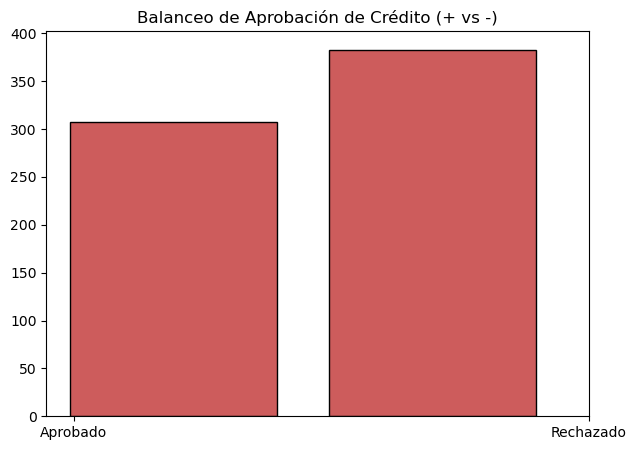

In [12]:
# 5. GRÁFICA DE BALANCEO (Columna Target)
plt.figure(figsize=(7, 5))
plt.hist(df_final_credit['Target'], bins=2, color='indianred', edgecolor='black', rwidth=0.8)
plt.title('Balanceo de Aprobación de Crédito (+ vs -)')
plt.xticks([-1, 1], ['Aprobado', 'Rechazado']) # Valores aproximados tras Z-score
plt.show()

In [13]:
# 6. DIVISIÓN TRAIN / TEST (80/20)
X = df_final_credit.drop('Target', axis=1).values
y = df_final_credit['Target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [15]:
print(f"¿Quedan nulos en X_train?: {np.isnan(X_train).sum()}")
print(f"¿Quedan nulos en X_test?: {np.isnan(X_test).sum()}")

¿Quedan nulos en X_train?: 0
¿Quedan nulos en X_test?: 0
